# Code in Homework 3 for MSDM 5054

Author: LAN, Tianwei 藍天蔚<br>
ID: 21230969<br>
Email: tlanaa@connect.ust.hk

# Problem 2

## 1.Polynomial Regression

Degree 1: R² = 0.9353, Adjusted R² = 0.9353
Degree 2: R² = 0.9616, Adjusted R² = 0.9603
Degree 3: R² = 0.9627, Adjusted R² = 0.9601
Degree 4: R² = 0.9634, Adjusted R² = 0.9593

Best model: degree = 2
Residual standard error (σ): 3.277

Fitted model formula:
Volume ≈ 10.7863 - 2.0921·Girth + 0.2545·Girth²


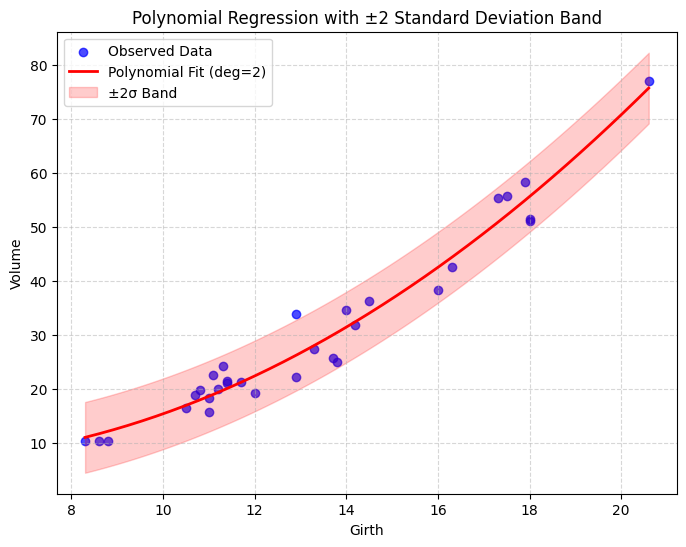

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Read data
df = pd.read_csv("trees.csv")
X = df["Girth"].values.reshape(-1, 1)
y = df["Volume"].values
n = len(y)

results = []
models = {}
polys = {}

for degree in range(1, 5):
    poly = PolynomialFeatures(degree=degree,include_bias=False)
    X_poly = poly.fit_transform(X)
    
    model = LinearRegression()
    model.fit(X_poly, y)
    
    r2 = model.score(X_poly, y)
    p = X_poly.shape[1] - 1 # no constant term taken into account
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    results.append((degree, r2, adj_r2))
    models[degree] = model
    polys[degree] = poly
    print(f"Degree {degree}: R² = {r2:.4f}, Adjusted R² = {adj_r2:.4f}")

# choose the model with highest Adj-R²
best_degree = max(results, key=lambda x: x[2])[0]
print(f"\nBest model: degree = {best_degree}")
best_poly = polys[best_degree]
best_model = models[best_degree]

# prediction and residual std computation
X_train_poly = best_poly.transform(X)
y_train_pred = best_model.predict(X_train_poly)
residuals = y - y_train_pred
p_best = X_train_poly.shape[1] - 1 
sigma = np.sqrt(np.sum(residuals**2) / (n - p_best - 1))
print(f"Residual standard error (σ): {sigma:.3f}")

# print model formula
print("\nFitted model formula:")
print(f"Volume ≈ {best_model.intercept_:.4f}", end="")
feature_names = best_poly.get_feature_names_out(['Girth'])
for i, name in enumerate(feature_names):
    coef = best_model.coef_[i]
    if '^' in name:
        base, exp = name.split('^')
        superscript = str.maketrans("0123456789", "⁰¹²³⁴⁵⁶⁷⁸⁹")
        pretty_name = base + exp.translate(superscript)
    else:
        pretty_name = name
    if coef >= 0:
        print(f" + {coef:.4f}·{pretty_name}", end="")
    else:
        print(f" - {abs(coef):.4f}·{pretty_name}", end="")
print()

# Plot
X_plot = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
X_plot_poly = best_poly.transform(X_plot)
y_plot = best_model.predict(X_plot_poly)

# ±2 std band
y_upper = y_plot + 2 * sigma
y_lower = y_plot - 2 * sigma

plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', alpha=0.7, label='Observed Data')
plt.plot(X_plot, y_plot, color='red', linewidth=2, label=f'Polynomial Fit (deg={best_degree})')
plt.fill_between(X_plot.flatten(), y_lower, y_upper, color='red', alpha=0.2, label='±2σ Band')
plt.xlabel('Girth')
plt.ylabel('Volume')
plt.title('Polynomial Regression with ±2 Standard Deviation Band')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("2(1)_1.png")
plt.show()





If use 5-fold Cross Validation instead:

Degree 1: CV R² = 0.8882 (±0.0951)
Degree 2: CV R² = 0.9246 (±0.0780)
Degree 3: CV R² = 0.9287 (±0.0777)
Degree 4: CV R² = 0.9104 (±0.0699)

Best model by 5-fold CV: degree = 3
Residual standard error (σ): 3.285

Fitted model formula:
Volume ≈ -23.5184 + 5.7801·Girth - 0.3256·Girth² + 0.0137·Girth³


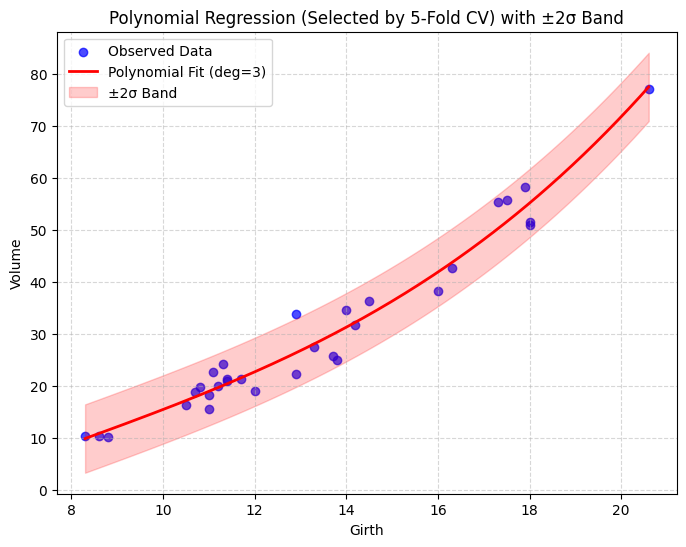

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

# read data
df = pd.read_csv("trees.csv")
X = df["Girth"].values.reshape(-1, 1)
y = df["Volume"].values
n = len(y)

# set up 5-fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
models = {}
polys = {}

for degree in range(1, 5):
    poly = PolynomialFeatures(degree=degree,include_bias=False)
    X_poly = poly.fit_transform(X)
    
    model = LinearRegression()
    
    scores = cross_val_score(model, X_poly, y, cv=kf, scoring='r2')
    mean_r2 = scores.mean()
    cv_scores.append((degree, mean_r2))
    polys[degree] = poly
    
    print(f"Degree {degree}: CV R² = {mean_r2:.4f} (±{scores.std()*2:.4f})")

# choose the model with highest CV R²
best_degree = max(cv_scores, key=lambda x: x[1])[0]
print(f"\nBest model by 5-fold CV: degree = {best_degree}")

# prediction and compute residual std
best_poly = polys[best_degree]
X_best_poly = best_poly.fit_transform(X)
best_model = LinearRegression()
best_model.fit(X_best_poly, y)

y_train_pred = best_model.predict(X_best_poly)
residuals = y - y_train_pred
p_best = X_best_poly.shape[1] - 1  # number of features excluding intercept
sigma = np.sqrt(np.sum(residuals**2) / (n - p_best - 1))
print(f"Residual standard error (σ): { sigma:.3f}")

# Print model formula
print("\nFitted model formula:")
print(f"Volume ≈ {best_model.intercept_:.4f}", end="")
feature_names = best_poly.get_feature_names_out(['Girth'])
for i, name in enumerate(feature_names):
    coef = best_model.coef_[i]
    if '^' in name:
        base, exp = name.split('^')
        superscript = str.maketrans("0123456789", "⁰¹²³⁴⁵⁶⁷⁸⁹")
        pretty_name = base + exp.translate(superscript)
    else:
        pretty_name = name
    if coef >= 0:
        print(f" + {coef:.4f}·{pretty_name}", end="")
    else:
        print(f" - {abs(coef):.4f}·{pretty_name}", end="")
print()

# Plot
X_plot = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
X_plot_poly = best_poly.transform(X_plot)
y_plot = best_model.predict(X_plot_poly)

# ±2 std band
y_upper = y_plot + 2 * sigma
y_lower = y_plot - 2 * sigma

plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', alpha=0.7, label='Observed Data')
plt.plot(X_plot, y_plot, color='red', linewidth=2, label=f'Polynomial Fit (deg={best_degree})')
plt.fill_between(X_plot.flatten(), y_lower, y_upper, color='red', alpha=0.2, label='±2σ Band')
plt.xlabel('Girth')
plt.ylabel('Volume')
plt.title('Polynomial Regression (Selected by 5-Fold CV) with ±2σ Band')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("2(1)_2.png")
plt.show() 

## 2.Polynomial Logistic Regression


Log-odds model: log(P/(1-P)) = 5.6239 + -3.3205·Girth + 0.2121·Girth²


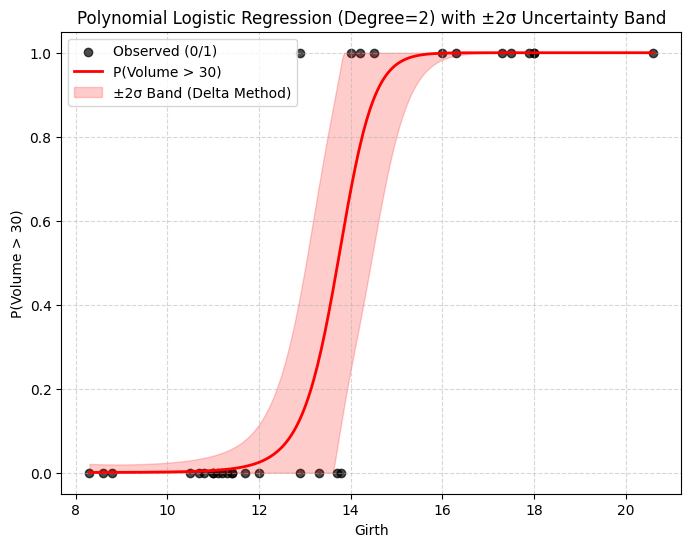

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures

# read data
df = pd.read_csv("trees.csv")
X = df["Girth"].values
y = (df["Volume"] > 30).astype(int).values  # Binary target

# polynomial features up to degree 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X.reshape(-1, 1))
X_poly_with_const = sm.add_constant(X_poly)

# fit
logit_model = sm.Logit(y, X_poly_with_const)
result = logit_model.fit(disp=0)

# Create smooth Girth values for plotting
Girth_plot = np.linspace(X.min(), X.max(), 300)
X_plot_poly = poly.transform(Girth_plot.reshape(-1, 1))
X_plot_with_const = sm.add_constant(X_plot_poly)

# predict and compute std of log-odds
pred_logit = result.predict(X_plot_with_const)
linear_pred = X_plot_with_const @ result.params 
cov = result.cov_params()
var_linear = np.array([x @ cov @ x.T for x in X_plot_with_const])
se_linear = np.sqrt(var_linear)
prob = 1 / (1 + np.exp(-linear_pred))
prob_se = prob * (1 - prob) * se_linear
prob_upper = prob + 2 * prob_se
prob_lower = prob - 2 * prob_se
prob_upper = np.clip(prob_upper, 0, 1)
prob_lower = np.clip(prob_lower, 0, 1)

# print the LR equation
params = result.params
intercept, b1, b2 = params
print(f"\nLog-odds model: log(P/(1-P)) = {intercept:.4f} + {b1:.4f}·Girth + {b2:.4f}·Girth²")

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='black', alpha=0.7, label='Observed (0/1)')
plt.plot(Girth_plot, pred_logit, color='red', linewidth=2, label='P(Volume > 30)')
plt.fill_between(Girth_plot, prob_lower, prob_upper, color='red', alpha=0.2, label='±2σ Band (Delta Method)')

plt.xlabel('Girth')
plt.ylabel('P(Volume > 30)')
plt.title('Polynomial Logistic Regression (Degree=2) with ±2σ Uncertainty Band')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(-0.05, 1.05)
plt.savefig("2(2).png")
plt.show()



## 3. Spline

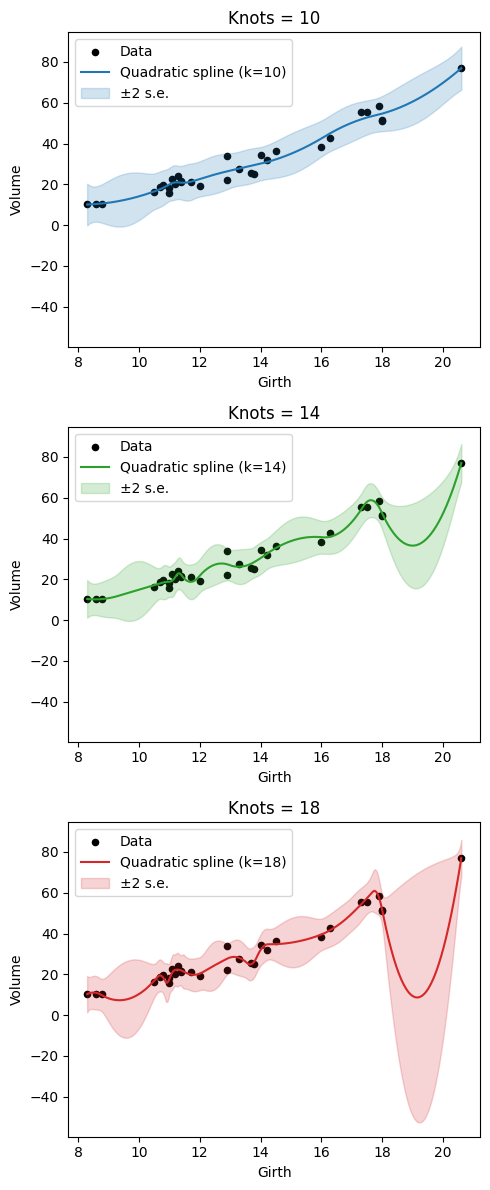

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import BSpline
from scipy.stats import t

df = pd.read_csv('trees.csv')
girth = df['Girth'].values
volume = df['Volume'].values
n = len(girth)

# construct Spline basis（degree=2）
def make_bspline_basis(x, n_knots, degree=2):
    knots = np.percentile(x, np.linspace(0, 100, n_knots))
    k = degree
    t = np.r_[(knots[0],)*k, knots, (knots[-1],)*k]
    n_basis = len(t) - k - 1
    B = np.empty((len(x), n_basis))
    for i in range(n_basis):
        coef = np.zeros(n_basis)
        coef[i] = 1.0
        B[:, i] = BSpline(t, coef, k)(x)
    return B, t

# fit and predict
def fit_and_predict(x, y, n_knots, x_plot):
    B, t = make_bspline_basis(x, n_knots)
    beta = np.linalg.lstsq(B, y, rcond=None)[0]    # Least Square
    B_pred = np.empty((len(x_plot), B.shape[1]))
    for i in range(B.shape[1]):
        coef = np.zeros(B.shape[1])
        coef[i] = 1.0
        B_pred[:, i] = BSpline(t, coef, 2)(x_plot)
    y_hat = B_pred @ beta
    # residual and std
    resid = y - B @ beta
    sigma2 = np.sum(resid**2) / (n - B.shape[1])
    cov_beta = sigma2 * np.linalg.inv(B.T @ B)
    se_pred = np.sqrt(np.sum((B_pred @ cov_beta) * B_pred, axis=1) + sigma2)
    return y_hat, se_pred

# plot
knots_list = [10, 14, 18]
colors = ['tab:blue', 'tab:green', 'tab:red']
x_plot = np.linspace(girth.min(), girth.max(), 300)

fig, axes = plt.subplots(3, 1, figsize=(5, 12), sharey=True)
for ax, nk, color in zip(axes, knots_list, colors):
    y_hat, se = fit_and_predict(girth, volume, nk, x_plot)
    ax.scatter(girth, volume, color='black', s=20, label='Data')
    ax.plot(x_plot, y_hat, color=color, label=f'Quadratic spline (k={nk})')
    ax.fill_between(x_plot,
                    y_hat - 2*se,
                    y_hat + 2*se,
                    color=color, alpha=0.2, label='±2 s.e.')
    ax.set_xlabel('Girth')
    ax.set_ylabel('Volume')
    ax.set_title(f'Knots = {nk}')
    ax.legend()
plt.tight_layout()
plt.savefig("2(3).png")
plt.show()

## 4. Smoothing Spline selected by CV

Selected λ= 23.36
EDF: 4.10


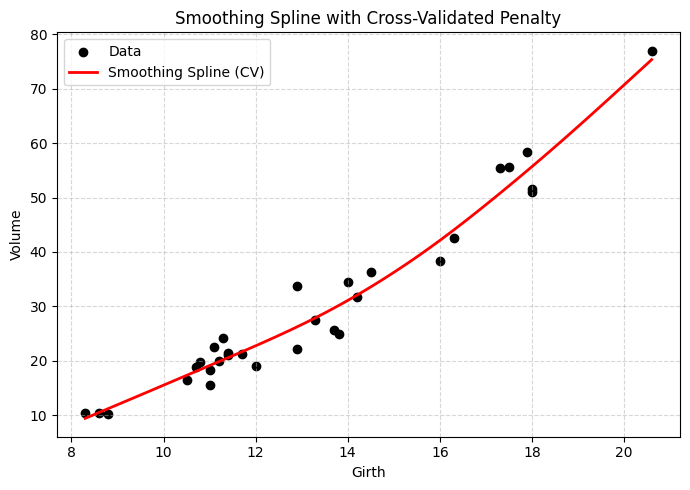

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pygam import LinearGAM, s
from sklearn.model_selection import KFold

df = pd.read_csv('trees.csv')
x = df['Girth'].values
y = df['Volume'].values
X = x.reshape(-1, 1)

# Define candidate penalties (λ)
lams = np.logspace(-1, 4, 20)

# Cross-validation to choose λ
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_lam, best_score = None, np.inf

for lam in lams:
    scores = []
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        try:
            gam = LinearGAM(s(0, lam=lam)).fit(X_tr, y_tr)
            pred = gam.predict(X_val)
            scores.append(np.mean((y_val - pred) ** 2))
        except Exception as e:
            scores.append(np.inf)
    avg_score = np.mean(scores)
    if avg_score < best_score:
        best_score = avg_score
        best_lam = lam

if best_lam is None:
    raise RuntimeError("CV failed to select a valid lambda. Try adjusting lam range.")

print(f"Selected λ= {best_lam:.2f}")

# fit 
gam_final = LinearGAM(s(0, lam=best_lam)).fit(X, y)

# compute EDF
edof = gam_final.statistics_['edof']
print(f"EDF: {edof:.2f}")

# Plot
x_plot = np.linspace(x.min(), x.max(), 200)
X_plot = x_plot.reshape(-1, 1)
y_plot = gam_final.predict(X_plot)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, color='black', label='Data')
plt.plot(x_plot, y_plot, color='red', linewidth=2, label='Smoothing Spline (CV)')
plt.xlabel('Girth')
plt.ylabel('Volume')
plt.title('Smoothing Spline with Cross-Validated Penalty')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("2(4).png")
plt.show()

## 5.GAM

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   31
Model:                         GLMGam   Df Residuals:                    24.00
Model Family:                Gaussian   Df Model:                         6.00
Link Function:               Identity   Scale:                          11.368
Method:                         PIRLS   Log-Likelihood:                -77.697
Date:                Tue, 28 Oct 2025   Deviance:                       272.83
Time:                        15:33:03   Pearson chi2:                     273.
No. Iterations:                     3   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Girth_s0      17.1398      6.187      2.770      0.0

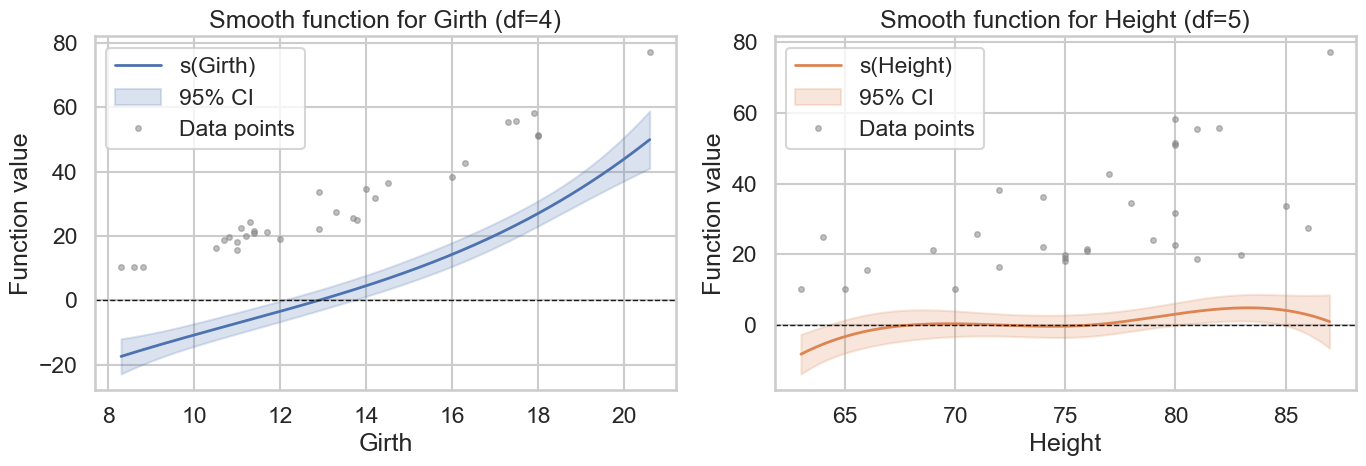

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.gam.api import GLMGam
from statsmodels.gam.smooth_basis import BSplines

df = pd.read_csv("trees.csv")
X = df[['Girth', 'Height']].copy()
y = df['Volume'].values

# construct BSpline basis
bs = BSplines(X, df=[4, 5], degree=[3, 3])  # Girth: df=4, Height: df=5

# fit GAM
gam = GLMGam(y, smoother=bs)
res = gam.fit()
print(res.summary())

# prediction
girth_seq = np.linspace(X['Girth'].min(), X['Girth'].max(), 200)
height_seq = np.linspace(X['Height'].min(), X['Height'].max(), 200)
girth_med = np.median(X['Girth'])
height_med = np.median(X['Height'])
X_girth = pd.DataFrame({
    'Girth': girth_seq,
    'Height': np.repeat(height_med, len(girth_seq))
})
X_height = pd.DataFrame({
    'Girth': np.repeat(girth_med, len(height_seq)),
    'Height': height_seq
})

def term_contribution(result, X_new, term_index):
    pred_new = result.get_prediction(exog_smooth=X_new)
    mean_new = pred_new.predicted_mean
    
    X_ref = X_new.copy()
    if term_index == 0:
        X_ref['Girth'] = girth_med
    else:
        X_ref['Height'] = height_med

    pred_ref = result.get_prediction(exog_smooth=X_ref)
    mean_ref = pred_ref.predicted_mean
    
    se_new = pred_new.se_mean
    se_ref = pred_ref.se_mean
    
    mean_diff = mean_new - mean_ref
    se_diff = np.sqrt(se_new**2 + se_ref**2)

    return mean_diff, se_diff

#  compute smooth function and CI
girth_eff, girth_se = term_contribution(res, X_girth, term_index=0)
height_eff, height_se = term_contribution(res, X_height, term_index=1)

z = 1.96
girth_lo = girth_eff - z * girth_se
girth_hi = girth_eff + z * girth_se
height_lo = height_eff - z * height_se
height_hi = height_eff + z * height_se

# Plot
sns.set(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Girth
axes[0].plot(girth_seq, girth_eff, color='C0', label='s(Girth)', linewidth=2)
axes[0].fill_between(girth_seq, girth_lo, girth_hi, color='C0', alpha=0.2, label='95% CI')
axes[0].plot(X['Girth'], y, 'o', color='gray', alpha=0.5, markersize=4, label='Data points')
axes[0].axhline(0.0, color='k', lw=1, ls='--')
axes[0].set_xlabel('Girth')
axes[0].set_ylabel('Function value')
axes[0].set_title('Smooth function for Girth (df=4)')
axes[0].legend()

# Height 
axes[1].plot(height_seq, height_eff, color='C1', label='s(Height)', linewidth=2)
axes[1].fill_between(height_seq, height_lo, height_hi, color='C1', alpha=0.2, label='95% CI')
axes[1].plot(X['Height'], y, 'o', color='gray', alpha=0.5, markersize=4, label='Data points')
axes[1].axhline(0.0, color='k', lw=1, ls='--')
axes[1].set_xlabel('Height')
axes[1].set_ylabel('Function value')
axes[1].set_title('Smooth function for Height (df=5)')
axes[1].legend()

plt.tight_layout()
plt.savefig("2(5)_1.png")
plt.show()


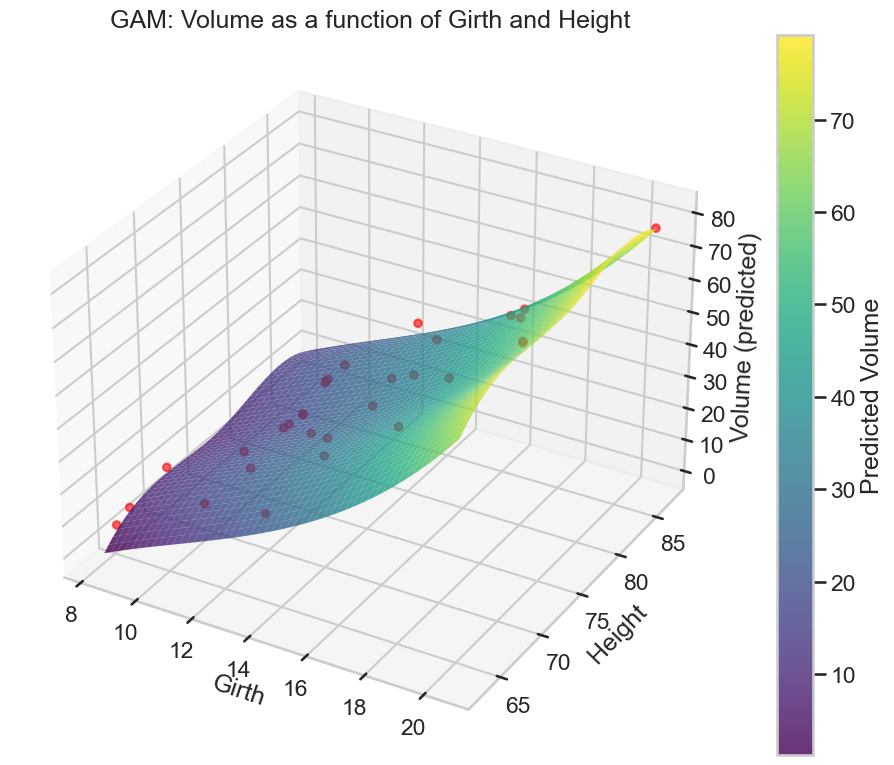

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

df = pd.read_csv("trees.csv")
X = df[['Girth', 'Height']].copy()
y = df['Volume'].values

# fit GAM
from statsmodels.gam.api import GLMGam
from statsmodels.gam.smooth_basis import BSplines

bs = BSplines(X, df=[4, 5], degree=[3, 3])
gam = GLMGam(y, smoother=bs)
res = gam.fit()

# get prediciton
girth_grid = np.linspace(X['Girth'].min(), X['Girth'].max(), 50)
height_grid = np.linspace(X['Height'].min(), X['Height'].max(), 50)
GG, HH = np.meshgrid(girth_grid, height_grid)
grid_df = pd.DataFrame({
    'Girth': GG.ravel(),
    'Height': HH.ravel()
})

pred_grid = res.get_prediction(exog_smooth=grid_df)
pred_mean = pred_grid.predicted_mean.reshape(GG.shape)

# 3D-Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(GG, HH, pred_mean, cmap='viridis', alpha=0.8, edgecolor='none')
ax.scatter(X['Girth'], X['Height'], y, color='red', s=30, alpha=0.6, label='Data points')

ax.set_xlabel('Girth')
ax.set_ylabel('Height')
ax.set_zlabel('Volume (predicted)')
ax.set_title('GAM: Volume as a function of Girth and Height')
fig.colorbar(surf, ax=ax, label='Predicted Volume')

plt.tight_layout()
plt.savefig("2(5)_2.png")
plt.show()


# Problem 3

# 1. Classification tree

training error: 0.0035


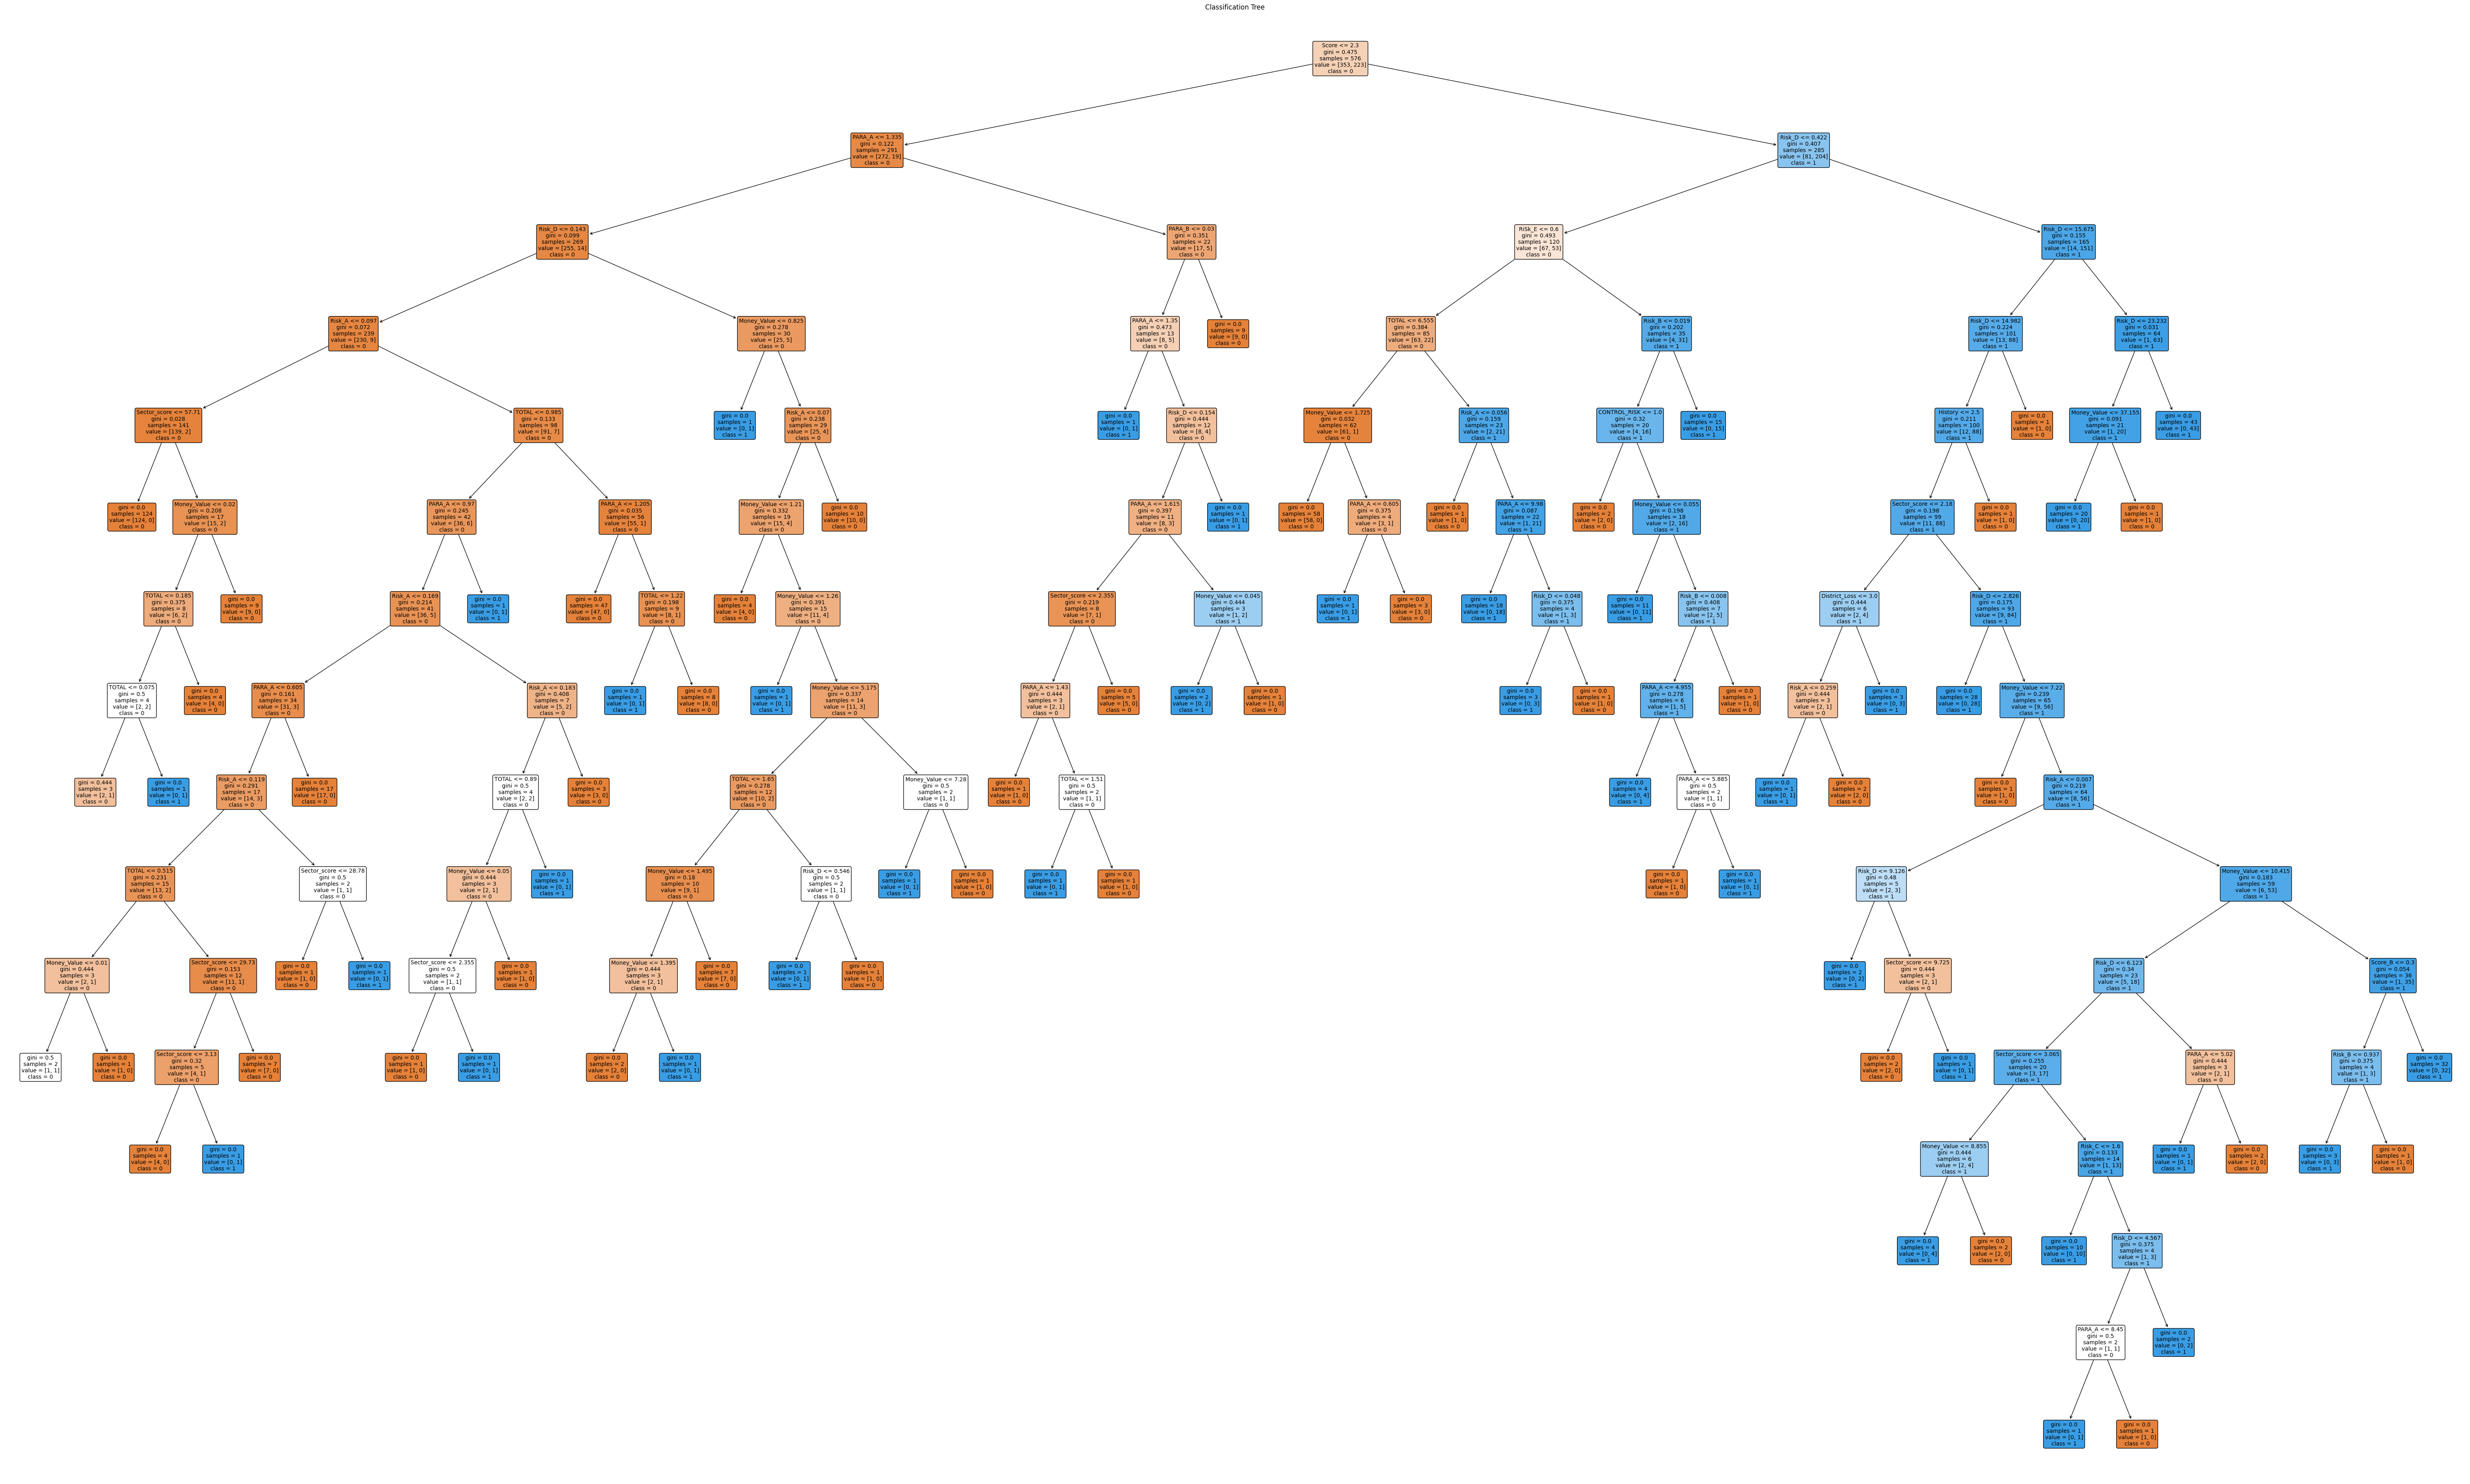

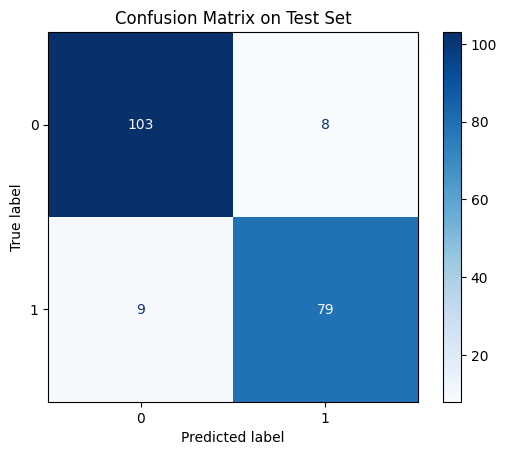

In [37]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score,confusion_matrix,ConfusionMatrixDisplay)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

dt_tr = pd.read_csv("audit_train.csv")
dt_te = pd.read_csv("audit_test.csv")
dt_tr.dropna(inplace=True)
dt_te.dropna(inplace=True)

X_tr = dt_tr.drop(columns=['Risk'])
y_tr = dt_tr['Risk']
X_te = dt_te.drop(columns=['Risk'])
y_te = dt_te['Risk']

# Feature Engineering
X_tr.drop(columns=['LOCATION_ID'],inplace=True)
X_te.drop(columns=['LOCATION_ID'],inplace=True)

# fit model
clf = DecisionTreeClassifier(criterion='gini',
                             max_depth=None,
                             random_state=21230969)
clf.fit(X_tr, y_tr)

# training error
train_acc = accuracy_score(y_tr, clf.predict(X_tr))
train_error = 1 - train_acc
print(f"training error: {train_error:.4f}")

# Plot the tree

plt.figure(figsize=(80,48))
plot_tree(clf,
          feature_names = X_tr.columns,
          class_names = [str(c) for c in clf.classes_],
          filled = True,
          rounded = True,
          fontsize = 10)
plt.title("Classification Tree")
plt.savefig("3(1)_1.png")
plt.show()

# Confusion matrix
y_pred = clf.predict(X_te)
cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix on Test Set")
plt.savefig("3(1)_2.png")
plt.show()

## 2. Pruned Trees

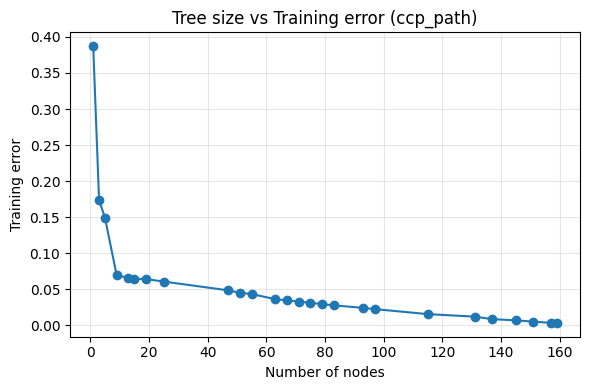

Best ccp_alpha = 0.003064
CV error of best tree = 0.1249


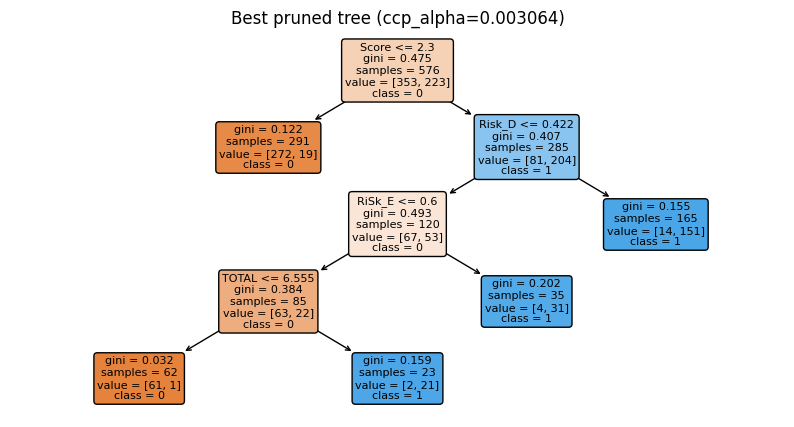

Test error of best pruned tree = 0.0503


In [ ]:
# Execute after 3(1)
from sklearn.model_selection import cross_val_score
import numpy as np


path = clf.cost_complexity_pruning_path(X_tr, y_tr)
ccp_alphas = path.ccp_alphas[::-1]                    # sort from small to large

train_err_list = []
cv_err_list  = []
node_list    = []

for alpha in ccp_alphas:
    tmp_clf = DecisionTreeClassifier(ccp_alpha=alpha,
                                     random_state=21230969)
    tmp_clf.fit(X_tr, y_tr)
    
    train_err = 1 - accuracy_score(y_tr, tmp_clf.predict(X_tr))
    cv_scores = cross_val_score(tmp_clf, X_tr, y_tr, cv=5)      # 5-fold CV
    cv_err    = 1 - cv_scores.mean()
    
    train_err_list.append(train_err)
    cv_err_list.append(cv_err)
    node_list.append(tmp_clf.tree_.node_count)

plt.figure(figsize=(6,4))
plt.plot(node_list, train_err_list, marker='o')
plt.xlabel("Number of nodes")
plt.ylabel("Training error")
plt.title("Tree size vs Training error (ccp_path)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("3(2)_1.png",)
plt.show()

# Retrain the best tree with least CV error
best_alpha = ccp_alphas[np.argmin(cv_err_list)]
print(f"Best ccp_alpha = {best_alpha:.6f}")
print(f"CV error of best tree = {min(cv_err_list):.4f}")

best_tree = DecisionTreeClassifier(ccp_alpha=best_alpha,
                                   random_state=21230969)
best_tree.fit(X_tr, y_tr)

# Plot the tree
plt.figure(figsize=(10,5))
plot_tree(best_tree,
          feature_names=X_tr.columns,
          class_names=[str(c) for c in best_tree.classes_],
          filled=True, rounded=True, fontsize=8)
plt.title(f"Best pruned tree (ccp_alpha={best_alpha:.6f})")
plt.savefig("3(2)_2.png")
plt.show()

# train error
y_best_pred = best_tree.predict(X_te)
test_err = 1 - accuracy_score(y_te, y_best_pred)
print(f"Test error of best pruned tree = {test_err:.4f}")

## 3. Random Forest

In [41]:
from sklearn.ensemble import RandomForestClassifier

m = 13          # max_features
ntree = 25      # n_estimators

rf = RandomForestClassifier(
        n_estimators=ntree,
        max_features=m,
        random_state=21230969,
        oob_score=False,
        n_jobs=-1)

rf.fit(X_tr, y_tr)

train_acc = accuracy_score(y_tr, rf.predict(X_tr))
train_error = 1 - train_acc
print(f"training error = {train_error:.4f}")

training error = 0.0052


In [42]:
m_candidates = [8, 12, 14, 16, 18]

best_m = None
best_train_err = float('inf')

for m in m_candidates:
    rf = RandomForestClassifier(
            n_estimators=ntree,
            max_features=m,
            random_state=21230969,
            n_jobs=-1)
    rf.fit(X_tr, y_tr)
    
    train_err = 1 - accuracy_score(y_tr, rf.predict(X_tr))
    print(f"{m}\t{train_err:.4f}")
    
    if train_err < best_train_err:
        best_train_err = train_err
        best_m = m
        best_rf = rf

print("-" * 15)
print(f"best m = {best_m}（best training error = {best_train_err:.4f}）")

test_err = 1 - accuracy_score(y_te, best_rf.predict(X_te))
print(f"test error = {test_err:.4f}")

8	0.0052
12	0.0069
14	0.0052
16	0.0069
18	0.0052
---------------
best m = 8（best training error = 0.0052）
test error = 0.0503


# Problem 4: Implementing Regression Tree

Below is a standard regression tree code generated by AI（`main process` and `load_xy()` function not included）, which I will modify according to the problem requirements.

In [70]:
# basic regression tree
import pandas as pd
import numpy as np

# ---------- Tool functions ----------
def mse(y):
    return 0 if len(y) == 0 else np.var(y) * len(y)

def best_split(X, y): # find the best split by MSE
    best_gain = -np.inf
    best_idx, best_thr = None, None
    current_mse = mse(y)
    n_features = X.shape[1]

    for fid in range(n_features):
        thresholds = np.unique(X[:, fid])
        for thr in thresholds[:-1]:          # the last one need no split
            left  = y[X[:, fid] <= thr]
            right = y[X[:, fid] >  thr]
            if len(left) == 0 or len(right) == 0:
                continue
            gain = current_mse - (mse(left) + mse(right))
            if gain > best_gain:
                best_gain = gain
                best_idx, best_thr = fid, thr
    return best_idx, best_thr

class RegressionTree:   # conversion regession tree
    
    def __init__(self):
        self.tree = None

    def _build(self, X, y, depth=0):
        # stop condition: sample_count <= 2 or only unique y left
        if len(y) <= 2 or len(np.unique(y)) == 1:
            return {"leaf": True, "val": np.mean(y)}

        idx, thr = best_split(X, y)
        if idx is None:                         # can't find valid split 
            return {"leaf": True, "val": np.mean(y)}

        left_mask  = X[:, idx] <= thr
        right_mask = ~left_mask
        return {
            "leaf": False,
            "feat": idx,
            "thr":  thr,
            "left":  self._build(X[left_mask],  y[left_mask],  depth+1),
            "right": self._build(X[right_mask], y[right_mask], depth+1)
        }

    def fit(self, X, y):
        self.tree = self._build(X, y)
        return self

    def _predict_one(self, x, node):
        if node["leaf"]:
            return node["val"]
        if x[node["feat"]] <= node["thr"]:
            return self._predict_one(x, node["left"])
        else:
            return self._predict_one(x, node["right"])

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])



In [88]:
# ---------- Main process ----------
def load_xy(path):
    df = pd.read_csv(path)
    feat_cols = ["Years", "Hits", "RBI", "Walks", "PutOuts", "Runs"]
    df = df[feat_cols + ["Salary"]].dropna()
    X = df[feat_cols].values
    y = df["Salary"].values
    return X, y

if __name__ == "__main__":
    X_tr, y_tr = load_xy("Hitters_train.csv")
    X_te, y_te = load_xy("Hitters_test.csv")

    model = RegressionTree().fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    test_mse = np.mean((y_te - y_pred) ** 2)
    print(f"Test MSE: {test_mse:.4f}")

Test MSE: 0.4918


In [ ]:
# Implemented Regression Tree
import pandas as pd
import numpy as np

# ---------- Tool functions ----------
def mae(y):
    '''substitute MSE with MAE'''
    if len(y) == 0:
        return 0.0
    return float(np.sum(np.abs(y - np.median(y))))

def best_split_2(X, y):
    best_gain = -np.inf
    best_idx, best_thr = None, None
    current_loss = mae(y) # use MAE instead
    n_features = X.shape[1]

    for fid in range(n_features):
        thresholds = np.unique(X[:, fid])
        for thr in thresholds[:-1]:
            left  = y[X[:, fid] <= thr]
            right = y[X[:, fid] >  thr]
            if len(left) == 0 or len(right) == 0:
                continue
            gain = current_loss - (mae(left) + mae(right)) # use MAE instead
            if gain > best_gain:
                best_gain = gain
                best_idx, best_thr = fid, thr
    return best_idx, best_thr

class ImplementedRegressionTree:

    def __init__(self, max_leaves=None, vgain=0.0):   # add vgain
        self.tree = None
        self.max_leaves = max_leaves or np.inf        # add max_leaves
        self.vgain = vgain                            # add vgain

    def _build(self, X, y, depth=0, node_cnt=1):    # add node count
        if len(y) <= 2 or len(np.unique(y)) == 1 or node_cnt >= self.max_leaves:    # add stop condition: node_cnt and max_leaves
            return {"leaf": True, "val": float(np.median(y))} # substitude mean with median
        idx, thr = best_split_2(X, y)
        if idx is None:
            return {"leaf": True, "val": float(np.median(y))} # substitude mean with median
        
        # compute gain by MAE
        gain = (mae(y) - (mae(y[X[:, idx] <= thr]) + mae(y[X[:, idx] > thr])))
        if gain < self.vgain:   # vgain stop
            return {"leaf": True, "val": float(np.median(y))}

        left_mask  = X[:, idx] <= thr
        right_mask = ~left_mask

        # update node_cnt in recursion
        left_node  = self._build(X[left_mask],  y[left_mask],  depth+1, node_cnt + 1)
        right_cnt  = self._count_leaves(left_node)
        right_node = self._build(X[right_mask], y[right_mask], depth+1, node_cnt + 1 + right_cnt)

        return {
            "leaf": False,
            "feat": idx,
            "thr":  thr,
            "left":  left_node,
            "right": right_node
        }
    
    # a new tool for counting leaves
    def _count_leaves(self, node):
        if node["leaf"]:
            return 1
        return self._count_leaves(node["left"]) + self._count_leaves(node["right"])

    def fit(self, X, y):
        self.tree = self._build(X, y)
        return self

    def _predict_one(self, x, node):
        if node["leaf"]:
            return node["val"]
        if x[node["feat"]] <= node["thr"]:
            return self._predict_one(x, node["left"])
        else:
            return self._predict_one(x, node["right"])

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])



In [90]:
# ---------- Main process ----------
def load_xy(path):
    df = pd.read_csv(path)
    feat_cols = ["Years", "Hits", "RBI", "Walks", "PutOuts", "Runs"]
    df = df[feat_cols + ["Salary"]].dropna()
    X = df[feat_cols].values
    y = df["Salary"].values
    return X, y

if __name__ == "__main__":
    X_tr, y_tr = load_xy("Hitters_train.csv")
    X_te, y_te = load_xy("Hitters_test.csv")

    model = ImplementedRegressionTree(vgain=2.0,max_leaves=8).fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    test_mse = np.mean((y_te - y_pred) ** 2)
    print(f"Test MSE: {test_mse:.4f}")

Test MSE: 0.2471


In [91]:
if __name__ == "__main__":
    X_tr, y_tr = load_xy("Hitters_train.csv")
    X_te, y_te = load_xy("Hitters_test.csv")

    vgains = [0.5, 1.0, 1.5, 2.0]
    leaves = [2, 4, 8, 16, 32]

    print("vgain\\leaves", end="")
    for l in leaves:
        print(f"{l:>8}", end="")
    print("\n" + "-" * (9 + 8 * len(leaves)))

    best_mse, best_v, best_l = np.inf, None, None

    for v in vgains:
        print(f"{v:>7} |", end="")
        for l in leaves:
            model = ImplementedRegressionTree(vgain=v, max_leaves=l).fit(X_tr, y_tr)
            y_pred = model.predict(X_te)
            mse_val = float(np.mean((y_te - y_pred) ** 2))
            print(f"{mse_val:>8.4f}", end="")
            if mse_val < best_mse:
                best_mse, best_v, best_l = mse_val, v, l
        print()

    print("-" * (9 + 8 * len(leaves)))
    print(f"Best -> vgain={best_v}, leaves={best_l}, Test MSE={best_mse:.4f}")

vgain\leaves       2       4       8      16      32
-------------------------------------------------
    0.5 |  0.4431  0.4258  0.3140  0.3103  0.2510
    1.0 |  0.4431  0.4258  0.3140  0.5187  0.5195
    1.5 |  0.4431  0.4258  0.2982  0.5171  0.5192
    2.0 |  0.4431  0.4258  0.2471  0.5421  0.5421
-------------------------------------------------
Best -> vgain=2.0, leaves=8, Test MSE=0.2471
